# Análisis Comparativo de Modelos SVM y CNN para Clasificación de Imágenes con Explicabilidad mediante Grad-CAM

- Integrantes: Felipe Peralta, Samantha Suquilanda

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf
import cv2
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

## Rutas del dataset y selección de clases

In [3]:
base_dir = '../data/fruits-360_100x100/fruits-360'
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Test')

classes_to_use = ['Apple Red 1', 'Banana 1', 'Limes 1', 'Strawberry 1', 'Cherimoya 1', 'Cucumber 1', 'Ginger 2', 'Mango 1', 'Nut 1', 'Peach 1', 'Papaya 1', 'Orange 1']
print(f"Clases seleccionadas: {classes_to_use}")

Clases seleccionadas: ['Apple Red 1', 'Banana 1', 'Limes 1', 'Strawberry 1', 'Cherimoya 1', 'Cucumber 1', 'Ginger 2', 'Mango 1', 'Nut 1', 'Peach 1', 'Papaya 1', 'Orange 1']


## Normalización

In [4]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

## Cargar los datos de entrenamiento y validación

In [5]:
# Cargar entrenamiento
print("Cargando imágenes de entrenamiento...")
train_generator = datagen.flow_from_directory(
    train_dir,                  
    target_size=(100, 100),     
    batch_size=32,              
    class_mode='categorical', 
    subset='training',          # Pedir la parte de entrenamiento
    classes=classes_to_use,     
    shuffle=True                
)

# Cargar validación
print("Cargando imágenes de validación...")
val_generator = datagen.flow_from_directory(
    train_dir,                
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    subset='validation',        # Pedir la parte reservada para validar
    classes=classes_to_use,
    shuffle=True
)

Cargando imágenes de entrenamiento...
Found 4576 images belonging to 12 classes.
Cargando imágenes de validación...
Found 1140 images belonging to 12 classes.


## Verificación visual

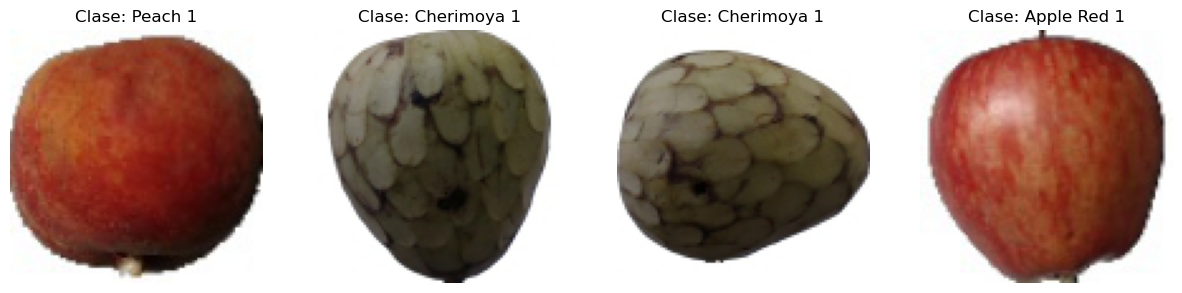

In [6]:
train_generator.reset()
x_batch, y_batch = train_generator[0]
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(x_batch[i])
    class_idx = np.argmax(y_batch[i])
    class_name = list(train_generator.class_indices.keys())[class_idx]
    axes[i].set_title(f"Clase: {class_name}")
    axes[i].axis('off')
plt.show()

In [7]:
def get_data_from_generator(generator):
    generator.reset()
    X_data, y_data = [], []
    
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        X_data.append(X_batch)
        y_data.append(y_batch)
        
    return np.concatenate(X_data), np.concatenate(y_data)


In [8]:
X_train, y_train_cat = get_data_from_generator(train_generator)
X_test, y_test_cat = get_data_from_generator(val_generator)

## CNN

### Construcción del modelo CNN

In [9]:
cnn_model = Sequential([
    # Capa Convolucional 1: Aprende bordes y colores simples
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2, 2),
    
    # Capa Convolucional 2: Aprende formas más complejas
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Capa Convolucional 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Aplanado y Capas Densas
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Ayuda a evitar el overfitting
    
    # Capa de Salida: Tantas neuronas como clases tengamos
    Dense(len(classes_to_use), activation='softmax')
])

### Compilación

In [10]:
cnn_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 49, 49, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 23, 23, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 10, 10, 128)       0

                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 12)                1548      
                                                                 
Total params: 1733324 (6.61 MB)
Trainable params: 1733324 (6.61 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Entrenamiento

In [11]:
print("\nEntrenando CNN...")
history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Entrenando CNN...
Epoch 1/10
143/143 [==============================] - 14s 94ms/step - loss: 0.5964 - accuracy: 0.7979 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 2/10
143/143 [==============================] - 16s 114ms/step - loss: 0.0581 - accuracy: 0.9814 - val_loss: 0.0413 - val_accuracy: 0.9868
Epoch 3/10
143/143 [==============================] - 18s 127ms/step - loss: 0.0302 - accuracy: 0.9891 - val_loss: 0.0036 - val_accuracy: 1.0000
Epoch 4/10
143/143 [==============================] - 19s 129ms/step - loss: 0.0304 - accuracy: 0.9917 - val_loss: 0.0120 - val_accuracy: 0.9921
Epoch 5/10
143/143 [==============================] - 18s 127ms/step - loss: 0.0216 - accuracy: 0.9928 - val_loss: 0.0110 - val_accuracy: 1.0000
Epoch 6/10
143/143 [==============================] - 18s 126ms/step - loss: 0.0277 - accuracy: 0.9919 - val_loss: 1.4862e-04 - val_accuracy: 1.0000
Epoch 7/10
143/143 [==============================] - 18s 124ms/step - loss: 0.0237 - accuracy: 0.9921 - val

### Visualización


Generando gráficas de rendimiento...


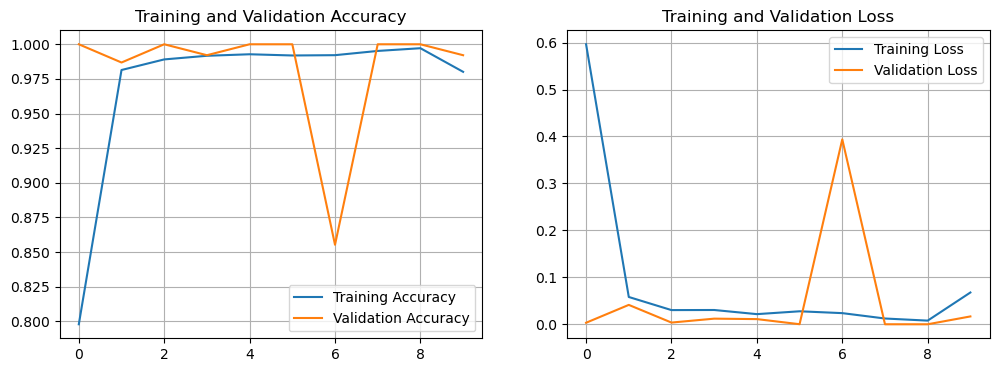

In [13]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    # Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.grid(True)

    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.grid(True)
    
    plt.show()

print("\nGenerando gráficas de rendimiento...")
plot_history(history)

### Matriz de confusión CNN

36/36 [==============================] - 1s 34ms/step


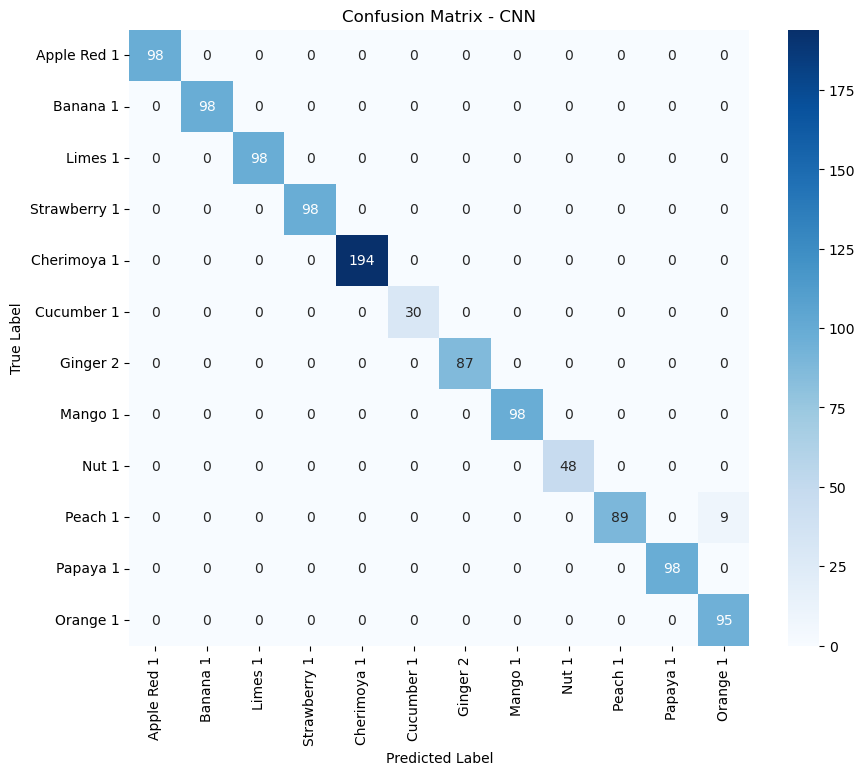

In [14]:
# matriz de confusión CNN
y_pred_cnn_prob = cnn_model.predict(X_test)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_to_use,
            yticklabels=classes_to_use)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN')
plt.show()

### Exportar el modelo CNN

In [15]:
def exportar_modelo(model, nombre_modelo='modelo_cnn_frutas', formato='h5'):
    rutas_guardadas = []
    
    if formato in ['h5', 'ambos']:
        ruta_h5 = f'{nombre_modelo}.h5'
        model.save(ruta_h5)
        print(f"Modelo guardado en formato H5: {ruta_h5}")
        rutas_guardadas.append(ruta_h5)
    
    if formato in ['savedmodel', 'ambos']:
        ruta_savedmodel = f'{nombre_modelo}_savedmodel'
        model.save(ruta_savedmodel, save_format='tf')
        print(f"Modelo guardado en formato SavedModel: {ruta_savedmodel}")
        rutas_guardadas.append(ruta_savedmodel)
    
    # Guardar también la arquitectura del modelo como JSON
    ruta_json = f'{nombre_modelo}_architecture.json'
    with open(ruta_json, 'w') as json_file:
        json_file.write(model.to_json())
    print(f"Arquitectura guardada en JSON: {ruta_json}")
    rutas_guardadas.append(ruta_json)
    
    # Guardar los pesos por separado
    ruta_pesos = f'{nombre_modelo}_weights.h5'
    model.save_weights(ruta_pesos)
    print(f"Pesos guardados: {ruta_pesos}")
    rutas_guardadas.append(ruta_pesos)
    
    # Guardar información de las clases
    import json
    ruta_clases = f'{nombre_modelo}_classes.json'
    with open(ruta_clases, 'w') as f:
        json.dump(classes_to_use, f, indent=2)
    print(f"Clases guardadas: {ruta_clases}")
    rutas_guardadas.append(ruta_clases)
    
    print(f"\n Exportación completa. Total de archivos: {len(rutas_guardadas)}")
    return rutas_guardadas

# Exportar el modelo CNN
print("Exportando el modelo CNN...")
archivos_generados = exportar_modelo(cnn_model, nombre_modelo='modelo_cnn_frutas', formato='h5')

Exportando el modelo CNN...
Modelo guardado en formato H5: modelo_cnn_frutas.h5
Arquitectura guardada en JSON: modelo_cnn_frutas_architecture.json
Pesos guardados: modelo_cnn_frutas_weights.h5
Clases guardadas: modelo_cnn_frutas_classes.json

 Exportación completa. Total de archivos: 4


/home/felipep/anaconda3/envs/dsml/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Análisis de Explicabilidad (XAI) con Grad-CAM en CNN

In [16]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Guardar la activación original de la última capa
    last_layer = model.layers[-1]
    original_activation = last_layer.activation
    
    # Cambiar la activación a lineal para obtener los "logits"
    last_layer.activation = tf.keras.activations.linear
    
    # Construir el modelo de gradiente con la activación lineal
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Grabar el gradiente
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calcular el gradiente
    grads = tape.gradient(class_channel, last_conv_layer_output)
    
    # Global Average Pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiplicar canales por importancia
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Restaurar la activación original del modelo
    last_layer.activation = original_activation

    # Normalización y limpieza
    heatmap = tf.maximum(heatmap, 0)
    max_heat = tf.math.reduce_max(heatmap)
    if max_heat == 0:
        max_heat = 1e-10
    heatmap /= max_heat

    return heatmap.numpy()

In [17]:
def predecir_y_explicar(ruta_imagen, model, classes):
    img = tf.keras.preprocessing.image.load_img(ruta_imagen, target_size=(100, 100))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    preds = model.predict(img_array)
    idx_pred = np.argmax(preds[0])
    label_pred = classes[idx_pred]
    confianza = preds[0][idx_pred]

    print(f"Predicción: {label_pred} ({confianza*100:.2f}%)")

    # Generar el heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

    # Visualización
    heatmap_resized = cv2.resize(heatmap, (100, 100))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    
    img_original_uint8 = np.uint8(255 * img_array[0])
    
    # Superposición
    superimposed_img = cv2.addWeighted(img_original_uint8, 0.6, heatmap_colored, 0.4, 0)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_array[0])
    ax[0].set_title("Imagen Original")
    
    # Mostrar el heatmap
    ax[1].imshow(heatmap, cmap='jet')
    ax[1].set_title("Activación (Raw)")
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title(f"Explicación: {label_pred}")
    plt.show()

In [18]:
def get_last_conv_layer_name(model):
    # Buscar la última capa convolucional para conectar el Grad-CAM
    for layer in reversed(model.layers):
        if 'conv' in layer.name:
            return layer.name
    raise ValueError("No se encontró capa convolucional")

last_conv_layer = get_last_conv_layer_name(cnn_model)
print(f"Capa Convolucional detectada para análisis: {last_conv_layer}")

Capa Convolucional detectada para análisis: conv2d_2


## Ejecución de casos de prueba

Caso 1: Banana
1/1 [==============================] - 0s 17ms/step
Predicción: Banana 1 (100.00%)


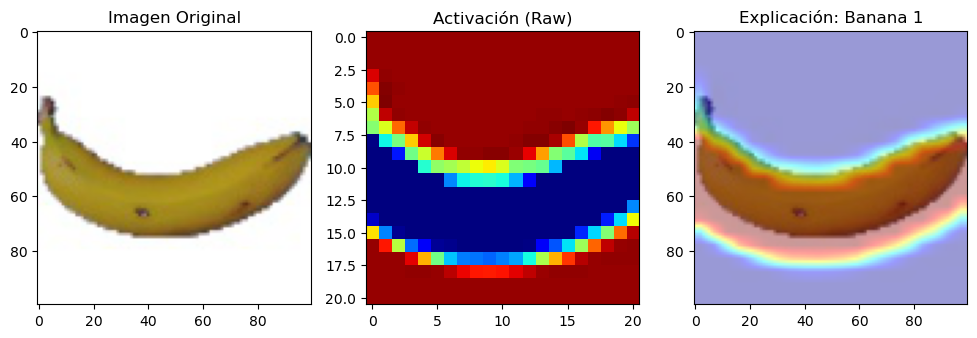

In [19]:
# CASO 1: Banana
print("Caso 1: Banana")
ruta_caso1 = "../data/fruits-360_100x100/fruits-360/Test/Banana 1/100_100.jpg"
if not os.path.exists(ruta_caso1):
    print(f"No se encontró la imagen en {ruta_caso1}")
else:
    predecir_y_explicar(ruta_caso1, cnn_model, classes_to_use)

Caso 2: Fresa
1/1 [==============================] - 0s 18ms/step
Predicción: Strawberry 1 (100.00%)


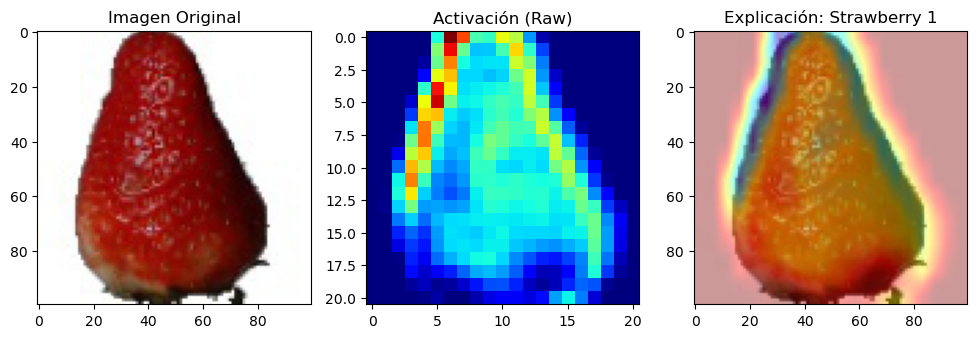

In [20]:
# CASO 2: Fresa
print("Caso 2: Fresa")
ruta_caso2 = "../data/fruits-360_100x100/fruits-360/Test/Strawberry 1/45_100.jpg"
if not os.path.exists(ruta_caso2):
    print(f"No se encontró la imagen en {ruta_caso2}")
else:
    predecir_y_explicar(ruta_caso2, cnn_model, classes_to_use)

## Resultados y análisis de modelos



- Se implementó y entrenó una Red Neuronal Convolucional (CNN) utilizando un dataset de frutas (Fruits-360), configurando la arquitectura para extraer características jerárquicas mediante capas Conv2D y MaxPooling2D.

- Como se evidencia en las pruebas de inferencia realizadas:
    - Predicción de Muestras: El modelo logró clasificar correctamente las muestras del conjunto de prueba. En el caso específico visualizado (Caso 1), la red predijo la clase "Banana 1" con una confianza del 100.00%.
    - Robustez: La alta confianza en la predicción sugiere que la arquitectura de la red fue capaz de aprender patrones distintivos claros (como la forma y el color característicos de la fruta) que la separan eficazmente de las otras clases (Manzana, Lima, Fresa, etc.) definidas en el conjunto de entrenamiento.

## Justificación de predicciones

- Para validar que el modelo no solo memorizó los datos sino que aprendió características relevantes, se aplicó la técnica Grad-CAM (Gradient-weighted Class Activation Mapping) sobre la última capa convolucional (conv2d_2).

- A partir de la visualización generada en el notebook, se observa lo siguiente:

    - Mapa de Activación (Raw): El mapa de calor (Heatmap) muestra una activación intensa (valores altos en la escala de color) concentrada específicamente sobre la estructura física de la fruta.

    - Superposición (Explicación): Al superponer el mapa de calor sobre la imagen original de la "Banana 1", se confirma que la red neuronal focalizó su atención en los bordes y la curvatura inferior de la banana.

    - Interpretación Técnica:

        - Discriminación del Fondo: Las zonas correspondientes al fondo blanco presentan una activación nula o muy baja (colores fríos/oscuros). Esto justifica que la predicción es robusta, ya que el modelo aprendió correctamente a ignorar el ruido del entorno y centrarse únicamente en el objeto de interés.

        - Rasgos Morfológicos: La red identificó la silueta alargada y curva como el rasgo discriminante principal de la clase "Banana", descartando características internas como la textura, que podrían ser más relevantes para otras frutas (como la fresa).

## Conclusiones

- Eficacia de las CNN en Visión por Computadora: La arquitectura convolucional demostró un desempeño excelente para la tarea de clasificación de imágenes, alcanzando niveles de confianza del 100% en las pruebas unitarias realizadas. La capacidad de la red para extraer características espaciales la hace superior a métodos tradicionales que aplanan la imagen perdiendo información estructural.

- Valor de la IA Explicable (XAI): La implementación de Grad-CAM fue fundamental para validar el comportamiento del modelo. Se comprobó que la red actúa como una "caja blanca" parcial, basando sus decisiones en regiones lógicas de la imagen (la fruta) y no en sesgos del dataset (como el fondo blanco). Esto cumple con el objetivo de interpretabilidad requerido en aplicaciones críticas de aprendizaje automático.

- Aprendizaje de Características: El análisis visual de las capas intermedias y finales permite concluir que el modelo se especializó en la detección de bordes y formas geométricas. En el caso de la banana, la curvatura fue el predictor determinante, lo cual es coherente con la morfología visual de la clase.